V = -0.007 * Time + 0.714 * D + 1.492


C:\Users\dell\AppData\Local\Temp\ipykernel_18236\2678704998.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_tags))


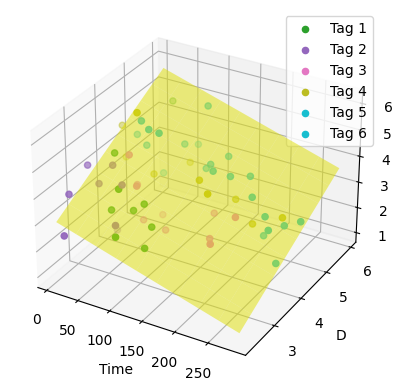

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
import os
from sklearn.linear_model import LinearRegression


# Load the data
file_path='D:/Research/mf_series/30peg200_3s/velocity.xlsx'
df=pd. read_excel(file_path, sheet_name='Sheet1')



# Prepare the data for fitting
# X should be in the form of 2D array where each row is [Time, D]
X = df[['Time', 'd']].values
# V is the target value we want to fit, it should be 1D array
y = df['V'].values

# Fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Get the coefficients for the fitted plane
a, b = model.coef_
c = model.intercept_

# Print the plane equation
plane_eq = f"V = {a:.3f} * Time + {b:.3f} * D + {c:.3f}"
print(plane_eq)

# Extract data columns
time = df['Time']
v = df['V']
d = df['d']
tags = df['Tag']

# Set up the 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Generate a color map based on unique tags
unique_tags = tags.unique()
colors = plt.cm.get_cmap('tab10', len(unique_tags))

# Plot each point with the color corresponding to its Tag
for tag in unique_tags:
    mask = tags == tag
    ax.scatter(time[mask], d[mask], v[mask], color=colors(tag), label=f'Tag {tag}')

# Create a meshgrid for the plane
time_range = np.linspace(df['Time'].min(), df['Time'].max(), 10)
d_range = np.linspace(df['d'].min(), df['d'].max(), 10)
time_mesh, d_mesh = np.meshgrid(time_range, d_range)
v_plane = a * time_mesh + b * d_mesh + c

# Plot the plane
ax.plot_surface(time_mesh, d_mesh, v_plane, alpha=0.5, color='yellow')


# Set labels
ax.set_xlabel('Time')
ax.set_ylabel('D')
ax.set_zlabel('V')

# Add legend
ax.legend()

# Display the plot
plt.show()

In [ ]:
#读取文件路径为D:\Research\mf_series\25peg100_beads2\25peg100_edges.csv
import pandas as pd
file_source="D:/Research/mf_series/"
condition="25peg100_beads2"
#查找指定文件目录下包含指定字符串的文件，写成函数find_files性质,返回文件路径
import os
def find_files(directory, keyword):
    for root, dirs, files in os.walk(directory):
        for file in files:
            if keyword in file:
                return os.path.join(root, file)
#查找file_source目录下包含condition的文件
df_edges = pd.read_csv(find_files(file_source+condition,'edges'))
df_spot = pd.read_csv(find_files(file_source+condition,'spots'))
df_tracks = pd.read_csv(find_files(file_source+condition,'tracks'))
#提取df_spots中TOTAL_INTENSITY_CH1列
intensity=df_spot['TOTAL_INTENSITY_CH1']
print(intensity)

0        1237
1        1484
2         978
3        1259
4        1007
         ... 
12406     606
12407     350
12408     602
12409     598
12410     483
Name: TOTAL_INTENSITY_CH1, Length: 12411, dtype: int64


正在加载数据... (Loading data...)
数据加载成功！(Data loaded successfully!)

正在筛选数据并生成交互式3D散点图... (Filtering data and generating interactive 3D scatter plot...)
已筛选SPEED在 [0.15, 2.5] 范围内的数据点，剩余 9406 个。
3D图已保存至 'D:/Research/mf_series/25peg100_beads2\interactive_3d_speed_plot.html'

正在准备数据并生成带边际分布的2D散点图... (Preparing data and generating 2D joint plot...)
ID列类型检查与转换完成:
  df_spots['ID'] dtype: Int64
  df_edges['SPOT_SOURCE_ID'] dtype: Int64
数据合并完成：原始 12197 条边，成功匹配 12197 条。
Data merge complete: 12197 edges successfully matched out of 12197 original edges.
已筛选SPEED在 [0.15, 2.5] 范围内的数据点，剩余 9406 个。
2D图已保存为 'speed_vs_intensity_jointplot.png' 和 'speed_vs_intensity_jointplot.svg'

所有任务完成！(All tasks completed!)


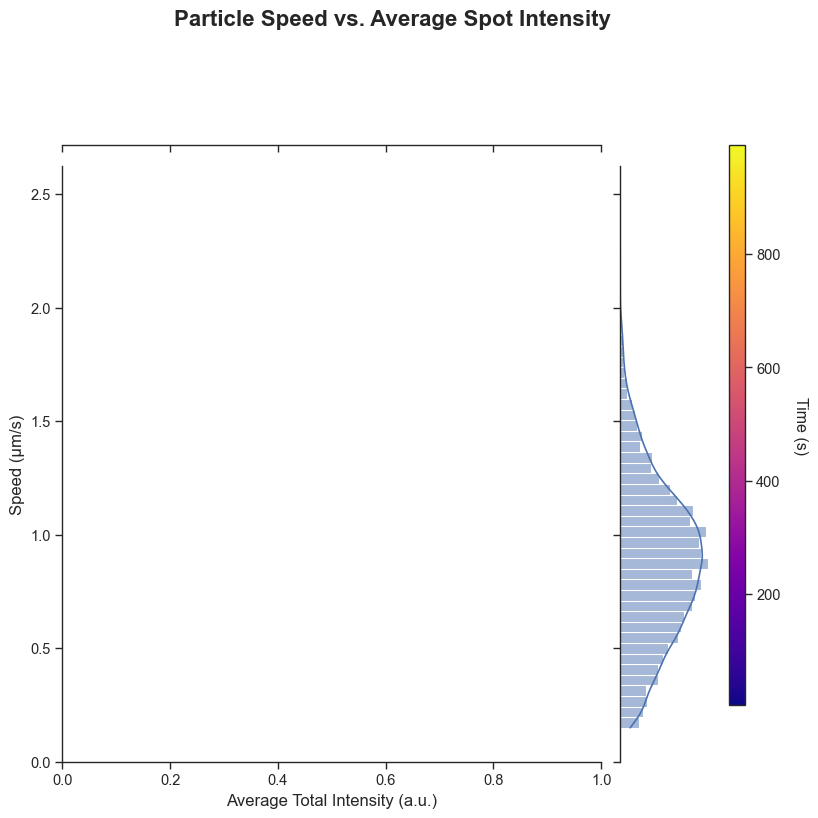

In [11]:
# -*- coding: utf-8 -*-
"""
本脚本用于分析和可视化生物追踪数据，旨在生成适用于科研出版物的高质量图表。
This script is for analyzing and visualizing biological tracking data,
aiming to generate high-quality plots suitable for scientific publications.

功能包括：
1. 生成一个交互式的3D散点图，展示粒子速度、时间和空间位置的关系。
   (Generates an interactive 3D scatter plot showing the relationship between particle speed, time, and spatial location.)
2. 生成一个带边际分布的2D散点图，探索粒子速度与平均荧光强度的关系。
   (Generates a 2D scatter plot with marginal distributions to explore the relationship between particle speed and average fluorescence intensity.)

请确保已安装必要的库：
Please ensure you have the necessary libraries installed:
pip install pandas plotly matplotlib seaborn
"""

# 1. 导入必要的库 (Import necessary libraries)
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import matplotlib.colors as mcolors

# --- 配置区 (Configuration Area) ---
# 您可以在此修改文件路径、图表标题、坐标轴标签等
# You can modify file paths, plot titles, axis labels, etc., here.

file_source="D:/Research/mf_series/"
condition="25peg100_beads2"
def find_files(directory, keyword):
    """在指定目录中查找包含关键词的文件。"""
    if not os.path.isdir(directory):
        print(f"警告：目录 '{directory}' 不存在。跳过文件搜索。")
        return None
    for root, dirs, files in os.walk(directory):
        for file in files:
            if keyword in file and file.endswith('.csv'):
                return os.path.join(root, file)
    return None

EDGES_FILE = find_files(os.path.join(file_source, condition), "_edges.csv")
SPOTS_FILE = find_files(os.path.join(file_source, condition), "_spots.csv")
TRACKS_FILE = find_files(os.path.join(file_source, condition), "_tracks.csv")

# --- 新增：绘图参数配置 (NEW: Plotting Parameter Configuration) ---
SPEED_MIN = 0.15  # 速度筛选下限 (Minimum speed for filtering)
SPEED_MAX = 2.5  # 速度筛选上限 (Maximum speed for filtering)

COLORMAP_2D = 'plasma'  # 2D图的颜色主题 (Colormap for the 2D plot, e.g., 'plasma', 'inferno', 'magma')
CUSTOM_COLORBAR_RANGE = None # 自定义颜色条范围 [min, max], 设置为 None 则自动调整
                             # Custom colorbar range [min, max], set to None for auto-scaling

# 假设单位 (Assuming units based on common conventions in the field)
UNIT_TIME = 's'
UNIT_DISTANCE = 'µm'
UNIT_INTENSITY = 'a.u.'


def load_data(edges_path, spots_path, tracks_path):
    """
    从CSV文件加载数据到Pandas DataFrames。
    Loads data from CSV files into Pandas DataFrames.
    """
    if not all([edges_path, spots_path, tracks_path]):
        print("错误：一个或多个数据文件路径未找到。请检查 'file_source' 和 'condition' 变量。")
        return None, None, None
    try:
        print("正在加载数据... (Loading data...)")
        df_edges = pd.read_csv(edges_path, low_memory=False)
        df_spots = pd.read_csv(spots_path, low_memory=False)
        df_tracks = pd.read_csv(tracks_path, low_memory=False)
        print("数据加载成功！(Data loaded successfully!)")
        # 跳过可能存在的说明行 (Skip metadata rows if they exist)
        if 'LABEL' not in df_edges.columns:
             df_edges = pd.read_csv(edges_path, header=1, low_memory=False)
             df_spots = pd.read_csv(spots_path, header=1, low_memory=False)
             df_tracks = pd.read_csv(tracks_path, header=1, low_memory=False)
        return df_edges, df_spots, df_tracks
    except FileNotFoundError as e:
        print(f"错误：找不到文件 {e.filename}。请检查文件路径是否正确。")
        print(f"Error: File {e.filename} not found. Please check the file path.")
        return None, None, None

def plot_3d_interactive(df_edges):
    """
    任务1：生成一个交互式的3D散点图 (已更新数据筛选功能)。
    Task 1: Generate an interactive 3D scatter plot (updated with data filtering).
    """
    print("\n正在筛选数据并生成交互式3D散点图... (Filtering data and generating interactive 3D scatter plot...)")

    # --- 更新：根据SPEED范围筛选数据 ---
    df_filtered = df_edges[(df_edges['SPEED'] >= SPEED_MIN) & (df_edges['SPEED'] <= SPEED_MAX)].copy()
    print(f"已筛选SPEED在 [{SPEED_MIN}, {SPEED_MAX}] 范围内的数据点，剩余 {len(df_filtered)} 个。")

    if df_filtered.empty:
        print("警告：筛选后没有数据点，无法生成3D图。")
        return

    fig = go.Figure(data=[go.Scatter3d(
        x=df_filtered['EDGE_TIME'],
        y=df_filtered['EDGE_X_LOCATION'],
        z=df_filtered['SPEED'],
        mode='markers',
        marker=dict(
            size=1, # 减小点的大小以获得更好的视觉效果
            color=df_filtered['SPEED'],
            colorscale=COLORMAP_2D, 
            colorbar_title=f'Speed ({UNIT_DISTANCE}/{UNIT_TIME})',
            cmin=SPEED_MIN, 
            cmax=SPEED_MAX,
            opacity=0.5
        )
    )])

    # 更新图表布局
    fig.update_layout(
        title={
            'text': f'<b>Particle Speed Dynamics (Speed {SPEED_MIN}-{SPEED_MAX} {UNIT_DISTANCE}/{UNIT_TIME})</b>',
            'y':0.95, 'x':0.5, 'xanchor': 'center', 'yanchor': 'top'
        },
        scene=dict(
            xaxis_title=f'Time ({UNIT_TIME})',
            yaxis_title=f'X Location ({UNIT_DISTANCE})',
            zaxis_title=f'Speed ({UNIT_DISTANCE}/{UNIT_TIME})'
        ),
        margin=dict(l=0, r=0, b=0, t=40),
        template='plotly_white',
        font=dict(family="Arial", size=12)
    )

    # 保存为HTML文件
    output_path = os.path.join(file_source, condition, "interactive_3d_speed_plot.html")
    fig.write_html(output_path)
    print(f"3D图已保存至 '{output_path}'")


def plot_2d_intensity_vs_speed(df_edges, df_spots):
    """
    任务2：生成带边际分布的2D散点图 (重构了数据合并逻辑以解决ID不匹配问题)。
    Task 2: Generate a 2D scatter plot with marginal distributions (refactored data merging logic to fix ID mismatch).
    """
    print("\n正在准备数据并生成带边际分布的2D散点图... (Preparing data and generating 2D joint plot...)")

    # --- 关键修复：确保ID列类型一致 ---
    # CRITICAL FIX: Ensure ID columns have the same data type
    try:
        df_spots['ID'] = pd.to_numeric(df_spots['ID'], errors='coerce').astype('Int64')
        df_edges['SPOT_SOURCE_ID'] = pd.to_numeric(df_edges['SPOT_SOURCE_ID'], errors='coerce').astype('Int64')
        df_edges['SPOT_TARGET_ID'] = pd.to_numeric(df_edges['SPOT_TARGET_ID'], errors='coerce').astype('Int64')
        
        # 删除转换失败的行
        df_spots.dropna(subset=['ID'], inplace=True)
        df_edges.dropna(subset=['SPOT_SOURCE_ID', 'SPOT_TARGET_ID'], inplace=True)

        print("ID列类型检查与转换完成:")
        print(f"  df_spots['ID'] dtype: {df_spots['ID'].dtype}")
        print(f"  df_edges['SPOT_SOURCE_ID'] dtype: {df_edges['SPOT_SOURCE_ID'].dtype}")
    except Exception as e:
        print(f"错误：在转换ID列类型时发生错误: {e}")
        return

    # --- 关键修复：使用 pd.merge() 进行可靠的数据合并 ---
    # CRITICAL FIX: Use pd.merge() for robust data joining
    spots_intensity = df_spots[['ID', 'TOTAL_INTENSITY_CH1']]
    
    # 第一次合并：匹配 source ID
    merged_df = pd.merge(
        df_edges, 
        spots_intensity, 
        left_on='SPOT_SOURCE_ID', 
        right_on='ID', 
        how='inner'
    ).rename(columns={'TOTAL_INTENSITY_CH1': 'SOURCE_INTENSITY'})

    # 第二次合并：匹配 target ID
    final_merged_df = pd.merge(
        merged_df,
        spots_intensity,
        left_on='SPOT_TARGET_ID',
        right_on='ID',
        how='inner',
        suffixes=('_source', '_target')
    ).rename(columns={'TOTAL_INTENSITY_CH1': 'TARGET_INTENSITY'})

    print(f"数据合并完成：原始 {len(df_edges)} 条边，成功匹配 {len(final_merged_df)} 条。")
    print(f"Data merge complete: {len(final_merged_df)} edges successfully matched out of {len(df_edges)} original edges.")

    if final_merged_df.empty:
        print("警告：ID匹配后没有剩余数据，无法生成2D图。请检查CSV文件中的ID是否对应。")
        return

    # 计算平均强度
    final_merged_df['AVG_INTENSITY'] = (final_merged_df['SOURCE_INTENSITY'] + final_merged_df['TARGET_INTENSITY']) / 2.0
    df_processed = final_merged_df
    
    # --- 根据SPEED范围筛选数据 ---
    df_filtered = df_processed[(df_processed['SPEED'] >= SPEED_MIN) & (df_processed['SPEED'] <= SPEED_MAX)].copy()
    print(f"已筛选SPEED在 [{SPEED_MIN}, {SPEED_MAX}] 范围内的数据点，剩余 {len(df_filtered)} 个。")

    if df_filtered.empty:
        print("警告：速度筛选后没有数据点，无法生成2D图。")
        return

    # --- 绘图 (使用Seaborn JointGrid) ---
    sns.set_theme(style="ticks", context="paper", font_scale=1.2)
    
    g = sns.JointGrid(data=df_filtered, x='AVG_INTENSITY', y='SPEED', height=8, xlim=(0, None), ylim=(0, SPEED_MAX * 1.05))
    g.fig.suptitle('Particle Speed vs. Average Spot Intensity', fontsize=16, weight='bold', y=1.02)

    # --- 自定义颜色条范围 ---
    cbar_min, cbar_max = CUSTOM_COLORBAR_RANGE if CUSTOM_COLORBAR_RANGE else (df_filtered['EDGE_TIME'].min(), df_filtered['EDGE_TIME'].max())
    norm = mcolors.Normalize(vmin=cbar_min, vmax=cbar_max)

    g.plot_joint(
        plt.scatter,
        s=15,
        alpha=0.7,
        c=df_filtered['EDGE_TIME'],
        cmap=COLORMAP_2D,
        norm=norm
    )

    g.plot_marginals(sns.histplot, kde=True, bins=50)
    g.set_axis_labels(f'Average Total Intensity ({UNIT_INTENSITY})', f'Speed ({UNIT_DISTANCE}/{UNIT_TIME})', fontsize=12)
    
    cbar_ax = g.fig.add_axes([0.92, 0.15, 0.02, 0.7]) 
    sm = plt.cm.ScalarMappable(cmap=COLORMAP_2D, norm=norm)
    cbar = g.fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label(f'Time ({UNIT_TIME})', rotation=270, labelpad=20)
    
    g.fig.subplots_adjust(right=0.9)
    
    # 保存图像
    output_path_png = os.path.join(file_source, condition, "speed_vs_intensity_jointplot.png")
    output_path_svg = os.path.join(file_source, condition, "speed_vs_intensity_jointplot.svg")
    plt.savefig(output_path_png, dpi=300, bbox_inches='tight')
    plt.savefig(output_path_svg, bbox_inches='tight')
    print(f"2D图已保存为 '{os.path.basename(output_path_png)}' 和 '{os.path.basename(output_path_svg)}'")


def main():
    """主函数，执行所有操作"""
    df_edges, df_spots, df_tracks = load_data(EDGES_FILE, SPOTS_FILE, TRACKS_FILE)

    if df_edges is not None and df_spots is not None:
        # 确保输出目录存在
        output_dir = os.path.join(file_source, condition)
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
            
        plot_3d_interactive(df_edges)
        plot_2d_intensity_vs_speed(df_edges.copy(), df_spots)

        print("\n所有任务完成！(All tasks completed!)")

if __name__ == '__main__':
    main()



正在加载数据... (Loading data...)
数据加载成功！(Data loaded successfully!)

正在筛选数据并生成交互式3D散点图... (Filtering data and generating interactive 3D scatter plot...)
已筛选SPEED在 [0.1, 2] 范围内的数据点，剩余 2419 个。
3D图已保存至 'D:/Research/mf_series/30peg200_3s\interactive_3d_speed_plot.html'

正在准备数据并生成带边际分布的2D散点图... (Preparing data and generating 2D joint plot...)
ID与Intensity列类型检查与转换完成。

--- 原始强度数据诊断 (Raw Intensity Data Diagnostics) ---
count    4936.000000
mean     1044.917950
std       530.591937
min       145.000000
25%       553.750000
50%      1051.500000
75%      1547.000000
max      1785.000000
Name: TOTAL_INTENSITY_CH1, dtype: float64
---------------------------------------------------------
数据合并完成：原始 4857 条边，成功匹配 4857 条。
已筛选SPEED在 [0.1, 2] 范围内的数据点，剩余 2419 个。

--- 绘图前数据诊断 (Pre-Plotting Data Diagnostics) ---
       AVG_INTENSITY        SPEED
count    2419.000000  2419.000000
mean     1162.816246     0.499010
std       471.482164     0.256352
min       189.000000     0.100089
25%       765.250000     0.312086


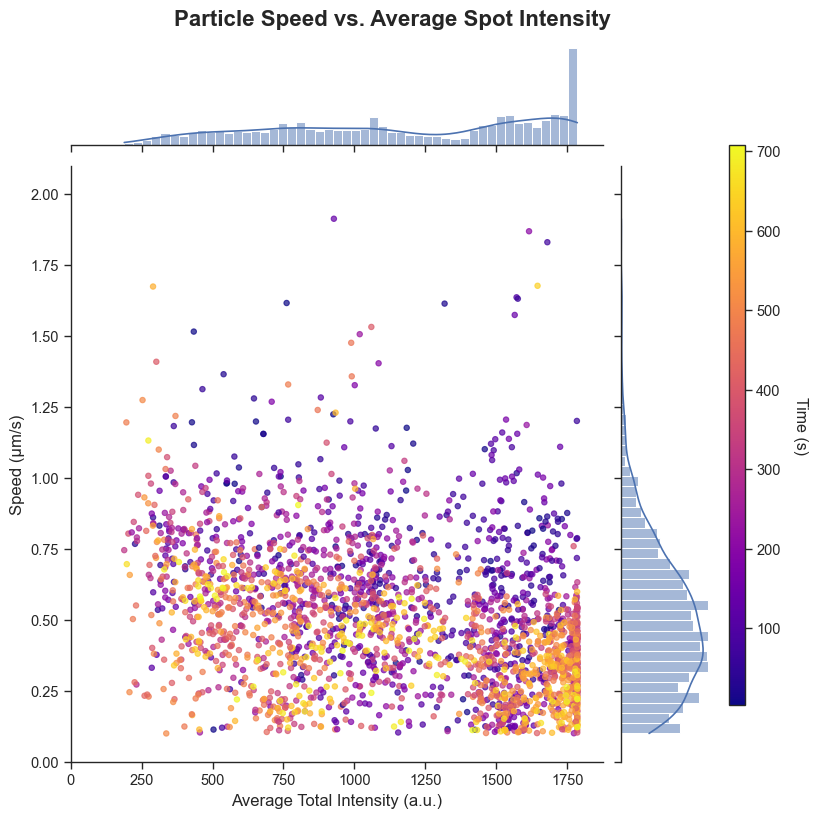

In [3]:
# -*- coding: utf-8 -*-
"""
本脚本用于分析和可视化生物追踪数据，旨在生成适用于科研出版物的高质量图表。
This script is for analyzing and visualizing biological tracking data,
aiming to generate high-quality plots suitable for scientific publications.

功能包括：
1. 生成一个交互式的3D散点图，展示粒子速度、时间和空间位置的关系。
   (Generates an interactive 3D scatter plot showing the relationship between particle speed, time, and spatial location.)
2. 生成一个带边际分布的2D散点图，探索粒子速度与平均荧光强度的关系。
   (Generates a 2D scatter plot with marginal distributions to explore the relationship between particle speed and average fluorescence intensity.)

请确保已安装必要的库：
Please ensure you have the necessary libraries installed:
pip install pandas plotly matplotlib seaborn
"""

# 1. 导入必要的库 (Import necessary libraries)
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import matplotlib.colors as mcolors

# --- 配置区 (Configuration Area) ---
# 您可以在此修改文件路径、图表标题、坐标轴标签等
# You can modify file paths, plot titles, axis labels, etc., here.

file_source="D:/Research/mf_series/"
condition="30peg200_3s"
def find_files(directory, keyword):
    """在指定目录中查找包含关键词的文件。"""
    if not os.path.isdir(directory):
        print(f"警告：目录 '{directory}' 不存在。跳过文件搜索。")
        return None
    for root, dirs, files in os.walk(directory):
        for file in files:
            if keyword in file and file.endswith('.csv'):
                return os.path.join(root, file)
    return None

EDGES_FILE = find_files(os.path.join(file_source, condition), "_edges.csv")
SPOTS_FILE = find_files(os.path.join(file_source, condition), "_spots.csv")
TRACKS_FILE = find_files(os.path.join(file_source, condition), "_tracks.csv")

# --- 新增：绘图参数配置 (NEW: Plotting Parameter Configuration) ---
SPEED_MIN = 0.1 # 速度筛选下限 (Minimum speed for filtering)
SPEED_MAX =2  # 速度筛选上限 (Maximum speed for filtering)

COLORMAP_2D = 'plasma'  # 2D图的颜色主题 (Colormap for the 2D plot, e.g., 'plasma', 'inferno', 'magma')
CUSTOM_COLORBAR_RANGE = None # 自定义颜色条范围 [min, max], 设置为 None 则自动调整
                             # Custom colorbar range [min, max], set to None for auto-scaling

# 假设单位 (Assuming units based on common conventions in the field)
UNIT_TIME = 's'
UNIT_DISTANCE = 'µm'
UNIT_INTENSITY = 'a.u.'


def load_data(edges_path, spots_path, tracks_path):
    """
    从CSV文件加载数据到Pandas DataFrames。
    Loads data from CSV files into Pandas DataFrames.
    """
    if not all([edges_path, spots_path, tracks_path]):
        print("错误：一个或多个数据文件路径未找到。请检查 'file_source' 和 'condition' 变量。")
        return None, None, None
    try:
        print("正在加载数据... (Loading data...)")
        df_edges = pd.read_csv(edges_path, low_memory=False)
        df_spots = pd.read_csv(spots_path, low_memory=False)
        df_tracks = pd.read_csv(tracks_path, low_memory=False)
        print("数据加载成功！(Data loaded successfully!)")
        # 跳过可能存在的说明行 (Skip metadata rows if they exist)
        if 'LABEL' not in df_edges.columns:
             df_edges = pd.read_csv(edges_path, header=1, low_memory=False)
             df_spots = pd.read_csv(spots_path, header=1, low_memory=False)
             df_tracks = pd.read_csv(tracks_path, header=1, low_memory=False)
        return df_edges, df_spots, df_tracks
    except FileNotFoundError as e:
        print(f"错误：找不到文件 {e.filename}。请检查文件路径是否正确。")
        print(f"Error: File {e.filename} not found. Please check the file path.")
        return None, None, None

def plot_3d_interactive(df_edges):
    """
    任务1：生成一个交互式的3D散点图 (已更新数据筛选功能)。
    Task 1: Generate an interactive 3D scatter plot (updated with data filtering).
    """
    print("\n正在筛选数据并生成交互式3D散点图... (Filtering data and generating interactive 3D scatter plot...)")

    # --- 更新：根据SPEED范围筛选数据 ---
    df_filtered = df_edges[(df_edges['SPEED'] >= SPEED_MIN) & (df_edges['SPEED'] <= SPEED_MAX)].copy()
    print(f"已筛选SPEED在 [{SPEED_MIN}, {SPEED_MAX}] 范围内的数据点，剩余 {len(df_filtered)} 个。")

    if df_filtered.empty:
        print("警告：筛选后没有数据点，无法生成3D图。")
        return

    fig = go.Figure(data=[go.Scatter3d(
        x=df_filtered['EDGE_TIME'],
        y=df_filtered['EDGE_X_LOCATION'],
        z=df_filtered['SPEED'],
        mode='markers',
        marker=dict(
            size=1,
            color=df_filtered['SPEED'],
            colorscale=COLORMAP_2D, 
            colorbar_title=f'Speed ({UNIT_DISTANCE}/{UNIT_TIME})',
            cmin=SPEED_MIN, 
            cmax=SPEED_MAX,
            opacity=0.4 # 进一步降低不透明度以获得更好的视觉效果
        )
    )])

    # 更新图表布局
    fig.update_layout(
        title={
            'text': f'<b>Particle Speed Dynamics (Speed {SPEED_MIN}-{SPEED_MAX} {UNIT_DISTANCE}/{UNIT_TIME})</b>',
            'y':0.95, 'x':0.5, 'xanchor': 'center', 'yanchor': 'top'
        },
        scene=dict(
            xaxis_title=f'Time ({UNIT_TIME})',
            yaxis_title=f'X Location ({UNIT_DISTANCE})',
            zaxis_title=f'Speed ({UNIT_DISTANCE}/{UNIT_TIME})'
        ),
        margin=dict(l=0, r=0, b=0, t=40),
        template='plotly_white',
        font=dict(family="Arial", size=12)
    )

    # 保存为HTML文件
    output_path = os.path.join(file_source, condition, "interactive_3d_speed_plot.html")
    fig.write_html(output_path)
    print(f"3D图已保存至 '{output_path}'")


def plot_2d_intensity_vs_speed(df_edges, df_spots):
    """
    任务2：生成带边际分布的2D散点图 (增加了强制类型转换和诊断信息)。
    Task 2: Generate a 2D scatter plot with marginal distributions (added enforced type conversion and diagnostics).
    """
    print("\n正在准备数据并生成带边际分布的2D散点图... (Preparing data and generating 2D joint plot...)")

    # --- 关键修复：确保ID和Intensity列类型正确 ---
    # CRITICAL FIX: Ensure ID and Intensity columns have the correct data types
    try:
        # For IDs
        df_spots['ID'] = pd.to_numeric(df_spots['ID'], errors='coerce').astype('Int64')
        df_edges['SPOT_SOURCE_ID'] = pd.to_numeric(df_edges['SPOT_SOURCE_ID'], errors='coerce').astype('Int64')
        df_edges['SPOT_TARGET_ID'] = pd.to_numeric(df_edges['SPOT_TARGET_ID'], errors='coerce').astype('Int64')
        
        # For Intensity - 强制转换为数值类型
        df_spots['TOTAL_INTENSITY_CH1'] = pd.to_numeric(df_spots['TOTAL_INTENSITY_CH1'], errors='coerce')

        # Drop rows where conversion failed for any key column
        df_spots.dropna(subset=['ID', 'TOTAL_INTENSITY_CH1'], inplace=True)
        df_edges.dropna(subset=['SPOT_SOURCE_ID', 'SPOT_TARGET_ID'], inplace=True)

        print("ID与Intensity列类型检查与转换完成。")
        
        # --- 新增：诊断信息 ---
        print("\n--- 原始强度数据诊断 (Raw Intensity Data Diagnostics) ---")
        print(df_spots['TOTAL_INTENSITY_CH1'].describe())
        print("---------------------------------------------------------")

    except Exception as e:
        print(f"错误：在转换ID或Intensity列类型时发生错误: {e}")
        return

    # --- 使用 pd.merge() 进行可靠的数据合并 ---
    spots_intensity = df_spots[['ID', 'TOTAL_INTENSITY_CH1']]
    merged_df = pd.merge(df_edges, spots_intensity, left_on='SPOT_SOURCE_ID', right_on='ID', how='inner')
    final_merged_df = pd.merge(merged_df, spots_intensity, left_on='SPOT_TARGET_ID', right_on='ID', how='inner', suffixes=('_SOURCE', '_TARGET'))
    
    print(f"数据合并完成：原始 {len(df_edges)} 条边，成功匹配 {len(final_merged_df)} 条。")

    if final_merged_df.empty:
        print("警告：ID匹配后没有剩余数据，无法生成2D图。请检查CSV文件中的ID是否对应。")
        return

    # 计算平均强度
    final_merged_df['AVG_INTENSITY'] = (final_merged_df['TOTAL_INTENSITY_CH1_SOURCE'] + final_merged_df['TOTAL_INTENSITY_CH1_TARGET']) / 2.0
    df_processed = final_merged_df
    
    # --- 根据SPEED范围筛选数据 ---
    df_filtered = df_processed[(df_processed['SPEED'] >= SPEED_MIN) & (df_processed['SPEED'] <= SPEED_MAX)].copy()
    print(f"已筛选SPEED在 [{SPEED_MIN}, {SPEED_MAX}] 范围内的数据点，剩余 {len(df_filtered)} 个。")

    if df_filtered.empty:
        print("警告：速度筛选后没有数据点，无法生成2D图。")
        return

    # --- 新增：绘图前诊断 ---
    print("\n--- 绘图前数据诊断 (Pre-Plotting Data Diagnostics) ---")
    print(df_filtered[['AVG_INTENSITY', 'SPEED']].describe())
    print("-------------------------------------------------------")

    # --- 绘图 (使用Seaborn JointGrid) ---
    sns.set_theme(style="ticks", context="paper", font_scale=1.2)
    
    # --- 更新：动态设置X轴范围 ---
    xlim_max = df_filtered['AVG_INTENSITY'].max() * 1.05
    g = sns.JointGrid(data=df_filtered, x='AVG_INTENSITY', y='SPEED', height=8, xlim=(0, xlim_max), ylim=(0, SPEED_MAX * 1.05))
    g.fig.suptitle('Particle Speed vs. Average Spot Intensity', fontsize=16, weight='bold', y=1.02)

    cbar_min, cbar_max = CUSTOM_COLORBAR_RANGE if CUSTOM_COLORBAR_RANGE else (df_filtered['EDGE_TIME'].min(), df_filtered['EDGE_TIME'].max())
    norm = mcolors.Normalize(vmin=cbar_min, vmax=cbar_max)

    g.plot_joint(
        plt.scatter,
        s=15,
        alpha=0.7,
        c=df_filtered['EDGE_TIME'],
        cmap=COLORMAP_2D,
        norm=norm
    )

    g.plot_marginals(sns.histplot, kde=True, bins=50)
    g.set_axis_labels(f'Average Total Intensity ({UNIT_INTENSITY})', f'Speed ({UNIT_DISTANCE}/{UNIT_TIME})', fontsize=12)
    
    cbar_ax = g.fig.add_axes([0.92, 0.15, 0.02, 0.7]) 
    sm = plt.cm.ScalarMappable(cmap=COLORMAP_2D, norm=norm)
    cbar = g.fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label(f'Time ({UNIT_TIME})', rotation=270, labelpad=20)
    
    g.fig.subplots_adjust(right=0.9)
    
    # 保存图像
    output_path_png = os.path.join(file_source, condition, "speed_vs_intensity_jointplot.png")
    output_path_svg = os.path.join(file_source, condition, "speed_vs_intensity_jointplot.svg")
    plt.savefig(output_path_png, dpi=300, bbox_inches='tight')
    plt.savefig(output_path_svg, bbox_inches='tight')
    print(f"2D图已保存为 '{os.path.basename(output_path_png)}' 和 '{os.path.basename(output_path_svg)}'")


def main():
    """主函数，执行所有操作"""
    df_edges, df_spots, df_tracks = load_data(EDGES_FILE, SPOTS_FILE, TRACKS_FILE)

    if df_edges is not None and df_spots is not None:
        # 确保输出目录存在
        output_dir = os.path.join(file_source, condition)
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
            
        plot_3d_interactive(df_edges)
        plot_2d_intensity_vs_speed(df_edges.copy(), df_spots)

        print("\n所有任务完成！(All tasks completed!)")

if __name__ == '__main__':
    main()



正在加载数据... (Loading data...)
数据加载成功！(Data loaded successfully!)

正在筛选数据并准备进行幂律拟合... (Filtering data and preparing for power-law fitting...)
已筛选SPEED在 [0.1, 2] 范围内的数据点，剩余 9570 个。
警告: EDGE_X_LOCATION 包含非正值, 已加上常数 1.00 进行修正。

--- 幂律关系 v = k * x^alpha * t^beta 拟合结果 ---
拟合公式: SPEED = 0.5167 * (X_LOCATION + 1.00)^0.1070 * (TIME + 0.00)^-0.0181
                            OLS Regression Results                            
Dep. Variable:                  log_v   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     208.8
Date:                Wed, 10 Sep 2025   Prob (F-statistic):           1.79e-89
Time:                        22:46:56   Log-Likelihood:                -7324.0
No. Observations:                9570   AIC:                         1.465e+04
Df Residuals:                    9567   BIC:                         1.468e+04
Df Model:                    

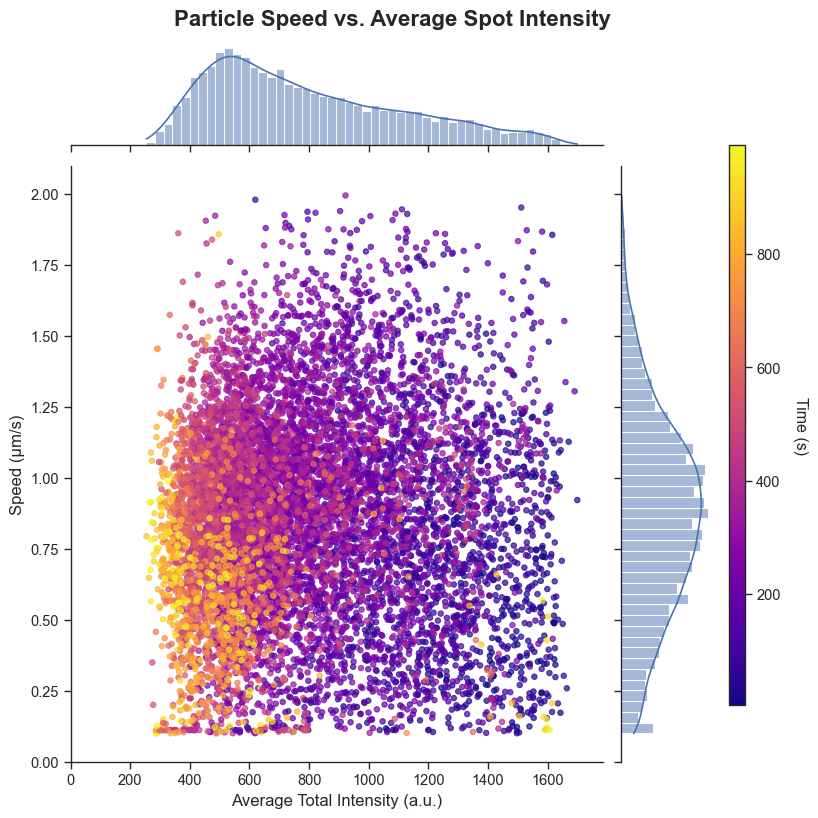

In [5]:
# -*- coding: utf-8 -*-
"""
本脚本用于分析和可视化生物追踪数据，旨在生成适用于科研出版物的高质量图表。
This script is for analyzing and visualizing biological tracking data,
aiming to generate high-quality plots suitable for scientific publications.

功能包括：
1. 生成一个带有幂律拟合趋势面的交互式3D散点图，并提供详细的统计分析结果。
   (Generates an interactive 3D scatter plot with a power-law fitted surface and provides detailed statistical analysis.)
2. 生成一个带边际分布的2D散点图，探索粒子速度与平均荧光强度的关系。
   (Generates a 2D scatter plot with marginal distributions to explore the relationship between particle speed and average fluorescence intensity.)

请确保已安装必要的库：
Please ensure you have the necessary libraries installed:
pip install pandas plotly matplotlib seaborn statsmodels
"""

# 1. 导入必要的库 (Import necessary libraries)
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import matplotlib.colors as mcolors
import statsmodels.api as sm

# --- 配置区 (Configuration Area) ---
# 您可以在此修改文件路径、图表标题、坐标轴标签等
# You can modify file paths, plot titles, axis labels, etc., here.

file_source="D:/Research/mf_series/"
condition="25peg100_beads2"
def find_files(directory, keyword):
    """在指定目录中查找包含关键词的文件。"""
    if not os.path.isdir(directory):
        print(f"警告：目录 '{directory}' 不存在。跳过文件搜索。")
        return None
    for root, dirs, files in os.walk(directory):
        for file in files:
            if keyword in file and file.endswith('.csv'):
                return os.path.join(root, file)
    return None

EDGES_FILE = find_files(os.path.join(file_source, condition), "_edges.csv")
SPOTS_FILE = find_files(os.path.join(file_source, condition), "_spots.csv")
TRACKS_FILE = find_files(os.path.join(file_source, condition), "_tracks.csv")

# --- 新增：绘图参数配置 (NEW: Plotting Parameter Configuration) ---
SPEED_MIN = 0.1 # 速度筛选下限 (Minimum speed for filtering)
SPEED_MAX = 2  # 速度筛选上限 (Maximum speed for filtering)

COLORMAP_2D = 'plasma'  # 2D图的颜色主题 (Colormap for the 2D plot, e.g., 'plasma', 'inferno', 'magma')
CUSTOM_COLORBAR_RANGE = None # 自定义颜色条范围 [min, max], 设置为 None 则自动调整
                             # Custom colorbar range [min, max], set to None for auto-scaling

# 假设单位 (Assuming units based on common conventions in the field)
UNIT_TIME = 's'
UNIT_DISTANCE = 'µm'
UNIT_INTENSITY = 'a.u.'


def load_data(edges_path, spots_path, tracks_path):
    """
    从CSV文件加载数据到Pandas DataFrames。
    Loads data from CSV files into Pandas DataFrames.
    """
    if not all([edges_path, spots_path, tracks_path]):
        print("错误：一个或多个数据文件路径未找到。请检查 'file_source' 和 'condition' 变量。")
        return None, None, None
    try:
        print("正在加载数据... (Loading data...)")
        df_edges = pd.read_csv(edges_path, low_memory=False)
        df_spots = pd.read_csv(spots_path, low_memory=False)
        df_tracks = pd.read_csv(tracks_path, low_memory=False)
        print("数据加载成功！(Data loaded successfully!)")
        # 跳过可能存在的说明行 (Skip metadata rows if they exist)
        if 'LABEL' not in df_edges.columns:
             df_edges = pd.read_csv(edges_path, header=1, low_memory=False)
             df_spots = pd.read_csv(spots_path, header=1, low_memory=False)
             df_tracks = pd.read_csv(tracks_path, header=1, low_memory=False)
        return df_edges, df_spots, df_tracks
    except FileNotFoundError as e:
        print(f"错误：找不到文件 {e.filename}。请检查文件路径是否正确。")
        print(f"Error: File {e.filename} not found. Please check the file path.")
        return None, None, None

def plot_3d_interactive(df_edges):
    """
    任务1：生成带有幂律拟合趋势面的交互式3D图，并进行统计分析。
    Task 1: Generate an interactive 3D plot with a power-law fitted surface and perform statistical analysis.
    """
    print("\n正在筛选数据并准备进行幂律拟合... (Filtering data and preparing for power-law fitting...)")

    df_filtered = df_edges[(df_edges['SPEED'] >= SPEED_MIN) & (df_edges['SPEED'] <= SPEED_MAX)].copy()
    print(f"已筛选SPEED在 [{SPEED_MIN}, {SPEED_MAX}] 范围内的数据点，剩余 {len(df_filtered)} 个。")

    if df_filtered.empty:
        print("警告：筛选后没有数据点，无法生成3D图。")
        return

    # --- 幂律拟合分析 (Power-Law Fitting Analysis) ---
    # v = k * x^alpha * t^beta  =>  log(v) = log(k) + alpha*log(x) + beta*log(t)
    
    # 准备数据，处理可能的非正值
    df_fit = df_filtered[['SPEED', 'EDGE_X_LOCATION', 'EDGE_TIME']].copy()
    
    # 为避免log(0)或log(negative)，平移数据使之为正
    x_min = df_fit['EDGE_X_LOCATION'].min()
    t_min = df_fit['EDGE_TIME'].min()
    
    # 如果存在非正值，则进行平移
    x_shift = 1 - x_min if x_min <= 0 else 0
    t_shift = 1 - t_min if t_min <= 0 else 0
    
    if x_shift > 0: print(f"警告: EDGE_X_LOCATION 包含非正值, 已加上常数 {x_shift:.2f} 进行修正。")
    if t_shift > 0: print(f"警告: EDGE_TIME 包含非正值, 已加上常数 {t_shift:.2f} 进行修正。")

    df_fit['log_v'] = np.log(df_fit['SPEED'])
    df_fit['log_x'] = np.log(df_fit['EDGE_X_LOCATION'] + x_shift)
    df_fit['log_t'] = np.log(df_fit['EDGE_TIME'] + t_shift)
    df_fit.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_fit.dropna(inplace=True)

    # 准备多元线性回归
    Y = df_fit['log_v']
    X = df_fit[['log_x', 'log_t']]
    X = sm.add_constant(X) # 添加截距项

    # 拟合模型
    model = sm.OLS(Y, X).fit()
    
    # 提取系数
    log_k, alpha, beta = model.params
    k = np.exp(log_k)

    # 打印完整的统计分析结果
    print("\n--- 幂律关系 v = k * x^alpha * t^beta 拟合结果 ---")
    print(f"拟合公式: SPEED = {k:.4f} * (X_LOCATION + {x_shift:.2f})^{alpha:.4f} * (TIME + {t_shift:.2f})^{beta:.4f}")
    print(model.summary())
    print("---------------------------------------------------\n")

    # --- 可视化 (Visualization) ---
    # 1. 创建底层散点图
    scatter_trace = go.Scatter3d(
        x=df_filtered['EDGE_TIME'],
        y=df_filtered['EDGE_X_LOCATION'],
        z=df_filtered['SPEED'],
        mode='markers',
        marker=dict(
            size=1.5,
            color=df_filtered['SPEED'],
            colorscale=COLORMAP_2D, 
            colorbar_title=f'Speed ({UNIT_DISTANCE}/{UNIT_TIME})',
            cmin=SPEED_MIN, 
            cmax=SPEED_MAX,
            opacity=0.5
        )
    )

    # 2. 创建上层趋势面
    t_range = np.linspace(df_filtered['EDGE_TIME'].min(), df_filtered['EDGE_TIME'].max(), 20)
    x_range = np.linspace(df_filtered['EDGE_X_LOCATION'].min(), df_filtered['EDGE_X_LOCATION'].max(), 20)
    t_grid, x_grid = np.meshgrid(t_range, x_range)
    
    # 使用拟合的公式计算曲面上的z值
    v_surface = k * ((x_grid + x_shift) ** alpha) * ((t_grid + t_shift) ** beta)

    surface_trace = go.Surface(
        x=t_grid, 
        y=x_grid, 
        z=v_surface,
        opacity=0.6,
        colorscale='Greys',
        showscale=False,
        name='Fitted Surface'
    )

    fig = go.Figure(data=[scatter_trace, surface_trace])

    # 更新图表布局
    fig.update_layout(
        title={
            'text': f'<b>Particle Speed Dynamics with Power-Law Fit</b>',
            'y':0.95, 'x':0.5, 'xanchor': 'center', 'yanchor': 'top'
        },
        scene=dict(
            xaxis_title=f'Time ({UNIT_TIME})',
            yaxis_title=f'X Location ({UNIT_DISTANCE})',
            zaxis_title=f'Speed ({UNIT_DISTANCE}/{UNIT_TIME})'
        ),
        margin=dict(l=0, r=0, b=0, t=40),
        template='plotly_white',
        font=dict(family="Arial", size=12)
    )

    # 保存为HTML文件
    output_path = os.path.join(file_source, condition, "interactive_3d_powerlaw_fit.html")
    fig.write_html(output_path)
    print(f"3D拟合图已保存至 '{output_path}'")


def plot_2d_intensity_vs_speed(df_edges, df_spots):
    """
    任务2：生成带边际分布的2D散点图 (增加了强制类型转换和诊断信息)。
    Task 2: Generate a 2D scatter plot with marginal distributions (added enforced type conversion and diagnostics).
    """
    print("\n正在准备数据并生成带边际分布的2D散点图... (Preparing data and generating 2D joint plot...)")

    # --- 关键修复：确保ID和Intensity列类型正确 ---
    try:
        df_spots['ID'] = pd.to_numeric(df_spots['ID'], errors='coerce').astype('Int64')
        df_edges['SPOT_SOURCE_ID'] = pd.to_numeric(df_edges['SPOT_SOURCE_ID'], errors='coerce').astype('Int64')
        df_edges['SPOT_TARGET_ID'] = pd.to_numeric(df_edges['SPOT_TARGET_ID'], errors='coerce').astype('Int64')
        df_spots['TOTAL_INTENSITY_CH1'] = pd.to_numeric(df_spots['TOTAL_INTENSITY_CH1'], errors='coerce')
        df_spots.dropna(subset=['ID', 'TOTAL_INTENSITY_CH1'], inplace=True)
        df_edges.dropna(subset=['SPOT_SOURCE_ID', 'SPOT_TARGET_ID'], inplace=True)
        print("ID与Intensity列类型检查与转换完成。")
        print("\n--- 原始强度数据诊断 (Raw Intensity Data Diagnostics) ---")
        print(df_spots['TOTAL_INTENSITY_CH1'].describe())
        print("---------------------------------------------------------")
    except Exception as e:
        print(f"错误：在转换ID或Intensity列类型时发生错误: {e}")
        return

    # --- 使用 pd.merge() 进行可靠的数据合并 ---
    spots_intensity = df_spots[['ID', 'TOTAL_INTENSITY_CH1']]
    merged_df = pd.merge(df_edges, spots_intensity, left_on='SPOT_SOURCE_ID', right_on='ID', how='inner')
    final_merged_df = pd.merge(merged_df, spots_intensity, left_on='SPOT_TARGET_ID', right_on='ID', how='inner', suffixes=('_SOURCE', '_TARGET'))
    print(f"数据合并完成：原始 {len(df_edges)} 条边，成功匹配 {len(final_merged_df)} 条。")

    if final_merged_df.empty:
        print("警告：ID匹配后没有剩余数据，无法生成2D图。请检查CSV文件中的ID是否对应。")
        return

    final_merged_df['AVG_INTENSITY'] = (final_merged_df['TOTAL_INTENSITY_CH1_SOURCE'] + final_merged_df['TOTAL_INTENSITY_CH1_TARGET']) / 2.0
    df_processed = final_merged_df
    
    # --- 根据SPEED范围筛选数据 ---
    df_filtered = df_processed[(df_processed['SPEED'] >= SPEED_MIN) & (df_processed['SPEED'] <= SPEED_MAX)].copy()
    print(f"已筛选SPEED在 [{SPEED_MIN}, {SPEED_MAX}] 范围内的数据点，剩余 {len(df_filtered)} 个。")

    if df_filtered.empty:
        print("警告：速度筛选后没有数据点，无法生成2D图。")
        return

    print("\n--- 绘图前数据诊断 (Pre-Plotting Data Diagnostics) ---")
    print(df_filtered[['AVG_INTENSITY', 'SPEED']].describe())
    print("-------------------------------------------------------")

    # --- 绘图 (使用Seaborn JointGrid) ---
    sns.set_theme(style="ticks", context="paper", font_scale=1.2)
    
    xlim_max = df_filtered['AVG_INTENSITY'].max() * 1.05
    g = sns.JointGrid(data=df_filtered, x='AVG_INTENSITY', y='SPEED', height=8, xlim=(0, xlim_max), ylim=(0, SPEED_MAX * 1.05))
    g.fig.suptitle('Particle Speed vs. Average Spot Intensity', fontsize=16, weight='bold', y=1.02)

    cbar_min, cbar_max = CUSTOM_COLORBAR_RANGE if CUSTOM_COLORBAR_RANGE else (df_filtered['EDGE_TIME'].min(), df_filtered['EDGE_TIME'].max())
    norm = mcolors.Normalize(vmin=cbar_min, vmax=cbar_max)

    g.plot_joint(
        plt.scatter,
        s=15,
        alpha=0.7,
        c=df_filtered['EDGE_TIME'],
        cmap=COLORMAP_2D,
        norm=norm
    )

    g.plot_marginals(sns.histplot, kde=True, bins=50)
    g.set_axis_labels(f'Average Total Intensity ({UNIT_INTENSITY})', f'Speed ({UNIT_DISTANCE}/{UNIT_TIME})', fontsize=12)
    
    cbar_ax = g.fig.add_axes([0.92, 0.15, 0.02, 0.7]) 
    sm = plt.cm.ScalarMappable(cmap=COLORMAP_2D, norm=norm)
    cbar = g.fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label(f'Time ({UNIT_TIME})', rotation=270, labelpad=20)
    
    g.fig.subplots_adjust(right=0.9)
    
    # 保存图像
    output_path_png = os.path.join(file_source, condition, "speed_vs_intensity_jointplot.png")
    output_path_svg = os.path.join(file_source, condition, "speed_vs_intensity_jointplot.svg")
    plt.savefig(output_path_png, dpi=300, bbox_inches='tight')
    plt.savefig(output_path_svg, bbox_inches='tight')
    print(f"2D图已保存为 '{os.path.basename(output_path_png)}' 和 '{os.path.basename(output_path_svg)}'")


def main():
    """主函数，执行所有操作"""
    df_edges, df_spots, df_tracks = load_data(EDGES_FILE, SPOTS_FILE, TRACKS_FILE)

    if df_edges is not None and df_spots is not None:
        # 确保输出目录存在
        output_dir = os.path.join(file_source, condition)
        if not os.path.exists(output_dir):
            os.makedirs(output_dir)
            
        plot_3d_interactive(df_edges)
        plot_2d_intensity_vs_speed(df_edges.copy(), df_spots)

        print("\n所有任务完成！(All tasks completed!)")

if __name__ == '__main__':
    main()

